### Example Fixed Project

The rest of this tutorial uses pre compiled ORBIT configs that are stored as .yaml files in the '~/configs/ folder. There are load and save methods available in ORBIT for working with .yaml files. These example projects each exhibit different functionalities within ORBIT. Using these examples and combinations of them, most project configurations can be modeled. 

In [1]:
import os
import pandas as pd
from ORBIT import ProjectManager, load_config

weather = pd.read_csv("data/boem_era5_41.0_-71.0.csv", parse_dates=["datetime"])\
            .set_index("datetime")

### Load the project configuration

In [2]:
fixed_config = load_config("configs/Revolution_Wind_base_install.yaml")  # Configs can be loaded with absolute or relative paths

print(type(fixed_config))                                         # They are loaded in as dictionaries.

print(f"Num turbines: {fixed_config['plant']['num_turbines']}")   # Once a configuration is loaded, different parameters can  
print(f"Turbine: {fixed_config['turbine']}")                      # be accessed using dict access.
print(f"\nSite: {fixed_config['site']}")

<class 'dict'>
Num turbines: 64
Turbine: 11MW_generic

Site: {'depth': 34.79, 'distance': 1713, 'distance_to_landfall': 74, 'mean_windspeed': 8.16811714317274}


### Phases

This fixed project represents a generic Offshore Wind farm with 50 6MW turbines. It includes 5 design modules and 6 installation modules as seen below. This is a common set of modules to run for a fixed bottom project. This config will model the procurement and installation of monopiles, scour protection, array system, export system, offshore substation and the turbines.

In [3]:
print(f"Design phases: {fixed_config['design_phases']}")
print(f"\nInstall phases: {list(fixed_config['install_phases'].keys())}")

Design phases: ['MonopileDesign', 'ScourProtectionDesign', 'CustomArraySystemDesign', 'ElectricalDesign']

Install phases: ['ArrayCableInstallation', 'ExportCableInstallation', 'MonopileInstallation', 'OffshoreSubstationInstallation', 'ScourProtectionInstallation', 'TurbineInstallation']


### Run

This project is always being modeled with the example weather project supplied that is representative of US East Coast wind farm locations.

In [4]:
project = ProjectManager(fixed_config, weather=weather)
project.run()

ORBIT library intialized at 'C:\ORBIT_procurement_by_year\ORBIT-dev\ORBIT\library'


Missing data in columns ['cable_length', 'bury_speed']; all values will be calculated.DeprecationWarning: C:\ORBIT_procurement_by_year\ORBIT-dev\ORBIT\ORBIT\manager.py:730
landfall dictionary will be deprecated and moved into [export_system][landfall].

### Top Level Outputs

ProjectManager offers several high level result categories:
- Installation CapEx
- System CapEx (procurement of BOS subcomponents)
- Turbine CapEx
- Soft CapEx (project management costs)
- Total CapEx
- Total installation time
- etc.

In [5]:
print(f"Installation CapEx:  {project.installation_capex/1e6:.0f} M")
print(f"System CapEx:        {project.system_capex/1e6:.0f} M")
print(f"Turbine CapEx:       {project.turbine_capex/1e6:.0f} M")
print(f"Soft CapEx:          {project.soft_capex/1e6:.0f} M")
print(f"Total CapEx:        {project.total_capex/1e6:.0f} M")

print(f"\nInstallation Time: {project.installation_time:.0f} h")

Installation CapEx:  900 M
System CapEx:        1294 M
Turbine CapEx:       1259 M
Soft CapEx:          988 M
Total CapEx:        4507 M

Installation Time: 52506 h


### CapEx Breakdown

In [6]:
# The breakdown of project costs by module is available  at 'capex_breakdown'
data = project.capex_detailed_soft_capex_breakdown

# Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(list(data.items()), columns=['Category', 'Value'])

# Add a "Total" row
total_row = pd.DataFrame([['Total', df['Value'].sum()]], columns=['Category', 'Value'])
df = pd.concat([df, total_row], ignore_index=True)

# Display the DataFrame
df.to_csv("Revolution_Wind_fixed_costs.csv")
display(df)

,Category,Value
0,Array System,7.283666e+07
1,Export System,4.594327e+08
2,Offshore Substation,2.367625e+08
3,Scour Protection,6.476800e+06
4,Substructure,5.180937e+08
5,Array System Installation,7.222187e+07
6,Export System Installation,5.254525e+07
7,Offshore Substation Installation,1.033916e+08
8,Scour Protection Installation,1.518677e+08
9,Substructure Installation,1.493446e+08


In [7]:
# The breakdown of project costs by module is available  at 'capex_breakdown'
data = project.capex_detailed_soft_capex_breakdown_per_kw

# Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(list(data.items()), columns=['Category', 'Value'])

# Add a "Total" row
total_row = pd.DataFrame([['Total', df['Value'].sum()]], columns=['Category', 'Value'])
df = pd.concat([df, total_row], ignore_index=True)

# Display the DataFrame
df.to_csv("Revolution_Wind_fixed_costs_per_kw.csv")
display(df)

,Category,Value
0,Array System,103.461161
1,Export System,652.603212
2,Offshore Substation,336.310303
3,Scour Protection,9.200000
4,Substructure,735.928599
5,Array System Installation,102.587884
6,Export System Installation,74.638145
7,Offshore Substation Installation,146.863083
8,Scour Protection Installation,215.721144
9,Substructure Installation,212.137154


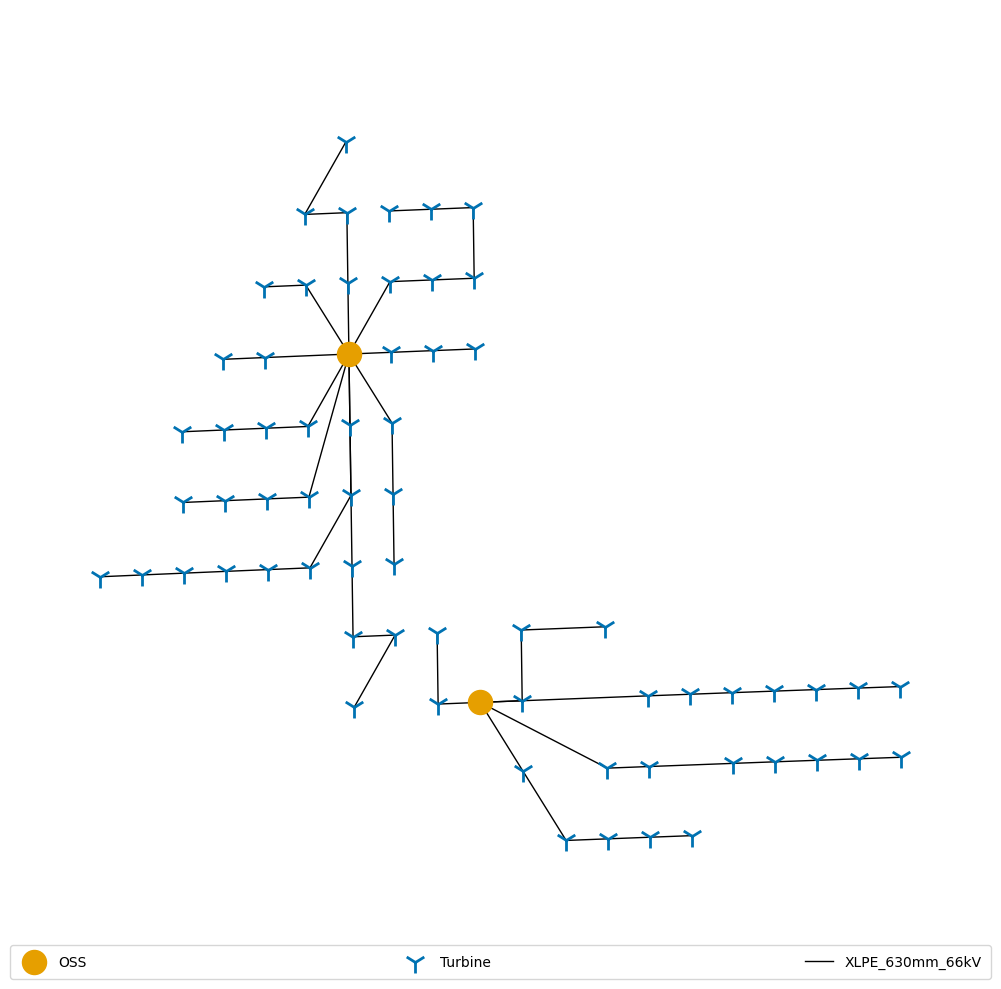

In [8]:
project.phases['CustomArraySystemDesign'].plot_array_system(show=True)

### Installation Actions

In [9]:
df = pd.DataFrame(project.actions)    # The project simulation logs are also available for all modules
df

,cost_multiplier,agent,action,duration,cost,level,time,phase,location,phase_name,max_waveheight,max_windspeed,transit_speed,site_depth,hub_height,per_trip
0,0.5,Array Cable Installation Vessel,Mobilize,72.0000,3.617565e+05,ACTION,0.000000,ArrayCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.5,Export Cable Installation Vessel,Mobilize,72.0000,3.617565e+05,ACTION,0.000000,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.5,Export Cable Burial Vessel,Mobilize,72.0000,3.617565e+05,ACTION,0.000000,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Onshore Construction,Onshore Construction,0.0000,1.226009e+07,ACTION,0.000000,ExportCableInstallation,Landfall,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.5,Heavy Lift Vessel,Mobilize,72.0000,9.369180e+05,ACTION,0.000000,OffshoreSubstationInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,NaN,WTIV,Attach Blade,3.5000,5.833333e+04,ACTION,26898.270591,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.79,132.0,NaN
4757,NaN,WTIV,Release Blade,1.0000,1.666667e+04,ACTION,26899.270591,TurbineInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4758,NaN,WTIV,Lift Blade,1.3200,2.200000e+04,ACTION,26900.590591,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.79,132.0,NaN
4759,NaN,WTIV,Attach Blade,3.5000,5.833333e+04,ACTION,26904.090591,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.79,132.0,NaN


In [10]:
# These logs can be sorted by phase by using DataFrame operations

turbine_install = df.loc[df['phase']=="TurbineInstallation"]
turbine_install

,cost_multiplier,agent,action,duration,cost,level,time,phase,location,phase_name,max_waveheight,max_windspeed,transit_speed,site_depth,hub_height,per_trip
1105,1.0,WTIV,Mobilize,168.0000,2.800000e+06,ACTION,8571.448391,TurbineInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1107,NaN,WTIV,Fasten Tower Section,4.0000,6.666667e+04,ACTION,8575.448391,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.79,132.0,NaN
1108,NaN,WTIV,Fasten Tower Section,4.0000,6.666667e+04,ACTION,8579.448391,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.79,132.0,NaN
1110,NaN,WTIV,Fasten Tower Section,4.0000,6.666667e+04,ACTION,8583.448391,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.79,132.0,NaN
1111,NaN,WTIV,Fasten Tower Section,4.0000,6.666667e+04,ACTION,8587.448391,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.79,132.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,NaN,WTIV,Attach Blade,3.5000,5.833333e+04,ACTION,26898.270591,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.79,132.0,NaN
4757,NaN,WTIV,Release Blade,1.0000,1.666667e+04,ACTION,26899.270591,TurbineInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4758,NaN,WTIV,Lift Blade,1.3200,2.200000e+04,ACTION,26900.590591,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.79,132.0,NaN
4759,NaN,WTIV,Attach Blade,3.5000,5.833333e+04,ACTION,26904.090591,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.79,132.0,NaN


In [11]:
# Operations can also be grouped to see a total amount of time spend on each operation

turbine_install.groupby(["action"]).sum()['duration']

action
Attach Blade               672.0000
Attach Nacelle             384.0000
Attach Tower Section      1536.0000
Delay                     1373.0000
Fasten Blade               288.0000
Fasten Nacelle             256.0000
Fasten Tower Section      1024.0000
Jackdown                    25.5104
Jackup                      25.5104
Lift Blade                 253.4400
Lift Nacelle                84.4800
Lift Tower Section         211.2000
Mobilize                   168.0000
Position Onsite            128.0000
Reequip                    128.0000
Release Blade              192.0000
Release Nacelle            192.0000
Release Tower Section      768.0000
Transit                  10791.9000
Name: duration, dtype: float64